## Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ankurzing/sentiment-analysis-for-financial-news")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment-analysis-for-financial-news' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-for-financial-news


In [14]:
import pandas as pd

df = pd.read_csv("/kaggle/input/sentiment-analysis-for-financial-news/all-data.csv", encoding='latin1', header=None, names=["labels", "text"])
df.head()

,labels,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [16]:
def create_balanced_dataset(df):

    # Count the instances of "negative"
    num_spam = df[df["labels"] == "negative"].shape[0]

    # Randomly sample "neutral" and "positive"instances to match the number of 2 instances
    label1_subset = df[df["labels"] == "neutral"].sample(num_spam, random_state=123)
    label2_subset = df[df["labels"] == "positive"].sample(num_spam, random_state=123)

    # Combine subsets with negatives
    balanced_df = pd.concat([label1_subset, label2_subset ,df[df["labels"] == "negative"]])

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["labels"].value_counts())

labels
neutral     604
positive    604
negative    604
Name: count, dtype: int64


In [17]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [10]:
import torch
from unsloth import FastModel
from transformers import AutoModelForSequenceClassification

# Disable fast generation for bert!
%env UNSLOTH_DISABLE_FAST_GENERATION = 1

max_seq_length = 2048
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = False # Use 4bit quantization to reduce memory usage. Can be False.


id2label = {0: "neutral", 1: "negative", 2: "positive"}
label2id = {"neutral":0,"negative":1, "positive":2}

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/ModernBERT-large",
    auto_model = AutoModelForSequenceClassification,
    max_seq_length = max_seq_length,
    dtype = dtype,
    num_labels  = 3,
    full_finetuning = True,
    id2label = id2label,
    label2id = label2id,
    load_in_4bit = load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
env: UNSLOTH_DISABLE_FAST_GENERATION=1
==((====))==  Unsloth 2026.9.11: Fast Modernbert patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Not planning a device map; the load builds ModernBertForSequenceClassification, not the planned ModernBertModel. Using `sequential`.
Unsloth: Float16 full finetuning uses more memory since we upcast weights to float32.


Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at unsloth/ModernBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`torch_dtype` is deprecated! Use `dtype` instead!


In [20]:
import datasets

train_dataset = datasets.Dataset.from_pandas(train_df, preserve_index=False)
validation_dataset = datasets.Dataset.from_pandas(validation_df, preserve_index=False)

def tokenize_function(examples):
    return tokenizer(examples["text"])

# Apply the tokenizer to the dataset
train_dataset = train_dataset.map(tokenize_function, batched = True)
val_dataset =   validation_dataset.map(tokenize_function, batched = True)

Map:   0%|          | 0/1268 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

In [21]:
# Map string labels to integer IDs
train_dataset = train_dataset.map(lambda examples: {"labels": [label2id[l] for l in examples["labels"]]}, batched=True)
val_dataset = val_dataset.map(lambda examples: {"labels": [label2id[l] for l in examples["labels"]]}, batched=True)

Map:   0%|          | 0/1268 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

In [22]:
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis = -1)
    return {"accuracy": accuracy_score(labels, preds)}

In [23]:
from transformers import TrainingArguments,Trainer
from unsloth import is_bfloat16_supported

trainer = Trainer(
    model = model,
    processing_class = tokenizer,
    eval_dataset = val_dataset,
    train_dataset = train_dataset,
    args = TrainingArguments(
        per_device_train_batch_size = 32,
        gradient_accumulation_steps = 1,
        warmup_steps = 5,
        num_train_epochs = 3, # bert-style models usually need more than 1 epoch
        # max_steps = 60,
        learning_rate = 5e-5,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.0025,
        eval_strategy = "steps",
        eval_steps = 0.1,  # Evaluate every 10% of total training steps
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use TrackIO/WandB etc
    ),
    compute_metrics = compute_metrics,
)

<a name="Train"></a>
## Train


In [24]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,268 | Num Epochs = 3 | Total steps = 120
O^O/ \_/ \    Batch size per device = 32 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (32 x 1 x 1) = 32
 "-____-"     Trainable parameters = 395,834,371 of 395,834,371 (100.00% trained)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:4091: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:4091: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:4091: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:4091: UserWarning: 'has_mkld

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss,Accuracy
12,0.928900,0.880477,0.519337
24,0.496300,0.572702,0.801105
36,0.259300,0.434083,0.817680
48,0.310000,0.500227,0.845304
60,0.163100,0.352948,0.856354
72,0.068300,0.340683,0.883978
84,0.108200,0.384783,0.850829
96,0.056000,0.375500,0.872928
108,0.115300,0.418401,0.867403
120,0.013000,0.442648,0.861878


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


<a name="Inference"></a>
## Inference


In [25]:
from transformers import pipeline

sentence1 = "We just finished training ModernBERT with Unsloth and it's amazing!"

classifier = pipeline("sentiment-analysis", model = model,tokenizer = tokenizer)

classifier(sentence1)

Device set to use cuda:0


[{'label': 'positive', 'score': 0.9145535230636597}]

In [26]:
import re
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score
from unsloth import FastLanguageModel


FastLanguageModel.for_inference(model)



predictions = []
ground_truths = []
unmatched_count = 0
test_df['labels'] = test_df['labels'].map(label2id)
sample = test_df[:250]
print(f"Starting evaluation on {len(sample)} test samples...")

# Initialize the classifier once outside the loop for efficiency
classifier = pipeline("sentiment-analysis", model = model,tokenizer = tokenizer)

for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Testing"):
    review_text = str(row["text"]).strip()
    true_label = int(row["labels"])

    # Pass the raw text directly to the pipeline
    outputs = classifier(review_text)

    # The pipeline output is a list of dicts like: [{'label': 'positive', 'score': 0.7439...}]
    predicted_sentiment_string = outputs[0]['label']

    # Convert the string label back to its integer representation using label2id
    if predicted_sentiment_string in label2id:
        pred_label = label2id[predicted_sentiment_string]
    else:
        # Handle unexpected labels, if any
        pred_label = -1
        unmatched_count += 1

    predictions.append(pred_label)
    ground_truths.append(true_label)


acc = accuracy_score(ground_truths, predictions) * 100
print(f"\n==========================================")
print(f"Final Test Accuracy: {acc:.2f}%")

Device set to use cuda:0


Starting evaluation on 250 test samples...


Testing: 100%|██████████| 250/250 [00:24<00:00, 10.14it/s]


Final Test Accuracy: 88.00%


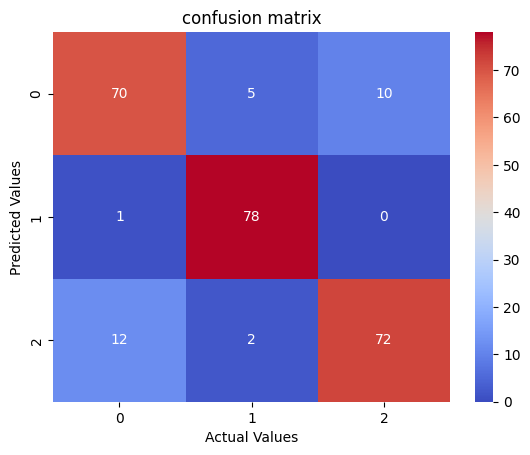

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Visualize confusion matrix for ModernBERT-large Classifier
sns.heatmap(confusion_matrix(ground_truths,predictions),annot= True, cmap = 'coolwarm', fmt='.0f')
plt.title('confusion matrix')
plt.ylabel('Predicted Values')
plt.xlabel('Actual Values')
plt.show()

<a name="Save Model"></a>
## Save Model


In [28]:
model.save_pretrained("bert_classification_lora")  # Local saving
tokenizer.save_pretrained("bert_classification_lora")

('bert_classification_lora/tokenizer_config.json',
 'bert_classification_lora/special_tokens_map.json',
 'bert_classification_lora/tokenizer.json')